<a href="https://colab.research.google.com/github/lifan149/notes/blob/main/fastai/Practical-Deep-Learning-for-Coders/dlfc_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

根据[fastbook第四节](https://github.com/fastai/fastbook/blob/master/04_mnist_basics.ipynb)记录的笔记

In [1]:
#hide
! [ -e /content ] && pip install -Uqq fastbook
import fastbook
fastbook.setup_book()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 122.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 97.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 820.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 88.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 63.3 MB/s eta 0:00:00
Mounted at /content/gdrive


In [2]:
#hide
from fastai.vision.all import *
from fastbook import *

matplotlib.rc('image', cmap='Greys')

根据教程尝试创建一个可以将任何图像分类为 3 或 7 的模型。下载一个仅包含这些数字图像的 MNIST 示例

In [3]:
path = untar_data(URLs.MNIST_SAMPLE)

In [4]:
#hide
Path.BASE_PATH = path

通过 fastai 添加的方法 ls 来查看这个目录中的内容。此方法返回一个名为 L 的特殊 fastai 类的对象，该类具有与 Python 内置列表相同的功能，以及更多功能。它的一个方便的功能是，在打印时，它会在列出项目本身之前显示项目计数（如果超过 10 个项目，它只显示前几个项目）：

In [5]:
path.ls()

(#3) [Path('valid'),Path('train'),Path('labels.csv')]

MNIST 数据集遵循机器学习数据集的常见布局：训练集和验证集（和/或测试集）的单独文件夹。

In [6]:
# 查看训练集的内容
(path/'train').ls()

(#2) [Path('train/3'),Path('train/7')]

有一个 3 的文件夹和一个 7 的文件夹。在机器学习术语中，我们说“3”和“7”是此数据集中的标签 （或目标）

In [7]:
threes = (path/'train'/'3').ls().sorted()
sevens = (path/'train'/'7').ls().sorted()
threes

(#6131) [Path('train/3/10.png'),Path('train/3/10000.png'),Path('train/3/10011.png'),Path('train/3/10031.png'),Path('train/3/10034.png'),Path('train/3/10042.png'),Path('train/3/10052.png'),Path('train/3/1007.png'),Path('train/3/10074.png'),Path('train/3/10091.png'),Path('train/3/10093.png'),Path('train/3/10097.png'),Path('train/3/10099.png'),Path('train/3/10116.png'),Path('train/3/10125.png'),Path('train/3/10137.png'),Path('train/3/10141.png'),Path('train/3/10144.png'),Path('train/3/10155.png'),Path('train/3/10161.png')...]

一张手写数字 3 的图片，取自手写数字 MNIST 数据集

In [8]:
im3_path = threes[1]
im3 = Image.open(im3_path)
im3

在计算机中，一切都表示为数字。要查看构成此图像的数字，我们必须将其转换为 NumPy 数组或 PyTorch 张量 。

**本质上，NumPy 数组（ndarray）和 PyTorch 张量（Tensor）在核心结构上都是多维数组**

**PyTorch 张量在 NumPy 数组的基础上，额外提供了 GPU 加速和自动求导的功能，使其更适合深度学习任务。**

将图像的一部分转为NumPy 数组

4:10 (对于行): 选取从索引为 4 的行开始，直到但不包括索引为 10 的行。换句话说，它会选择索引为 4, 5, 6, 7, 8, 9 的这 6 行。

4:10 (对于列): 这表示选取从索引为 4 的列开始，直到但不包括索引为 10 的列。同样地，它会选择索引为 4, 5, 6, 7, 8, 9 的这 6 列。

NumPy 从上到下、从左到右编制索引，因此此部分位于图像的左上角

In [9]:
array(im3)[4:10,4:10]

array([[  0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,  29],
       [  0,   0,   0,  48, 166, 224],
       [  0,  93, 244, 249, 253, 187],
       [  0, 107, 253, 253, 230,  48],
       [  0,   3,  20,  20,  15,   0]], dtype=uint8)

 PyTorch 张量也是如此

In [10]:
tensor(im3)[4:10,4:10]

tensor([[  0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,  29],
        [  0,   0,   0,  48, 166, 224],
        [  0,  93, 244, 249, 253, 187],
        [  0, 107, 253, 253, 230,  48],
        [  0,   3,  20,  20,  15,   0]], dtype=torch.uint8)

## 关于图像数据的多维数组
---

### **1. 彩色图像的三维数组结构**
- **维度定义**  
  彩色图像通常表示为 **三维数组**，结构为 `(高度, 宽度, 颜色通道)`，例如 RGB 图像的通道数为 3（红、绿、蓝）。  
  - **示例**：一个分辨率为 `1920x1080` 的 RGB 图像，其数组形状为 `(1080, 1920, 3)`。  
  - **通道顺序**：OpenCV 中默认通道顺序为 **BGR**（蓝、绿、红），而非 RGB。

- **像素值含义**  
  每个通道的像素值范围通常为 **0-255**，表示颜色强度：  
  - `0`：表示该通道无贡献（如红色通道为 0 时，无红色成分）。  
  - `255`：表示该通道最大强度。

---

### **2. 灰度图像的二维数组结构**
- **维度定义**  
  灰度图像仅包含亮度信息，因此简化为 **二维数组**，结构为 `(高度, 宽度)`。  
  - **示例**：同样分辨率 `1920x1080` 的灰度图像，数组形状为 `(1080, 1920)`。

- **像素值含义**  
  每个像素值直接表示亮度，范围仍为 **0-255**：  
  - `0`：纯黑色。  
  - `255`：纯白色，中间值表示不同灰度等级。

---

### **3. 内存存储与数组组织**
- **多维数组的线性化**  
  尽管逻辑上是多维结构，但计算机内存是线性地址空间。多维数组通过 **行优先顺序** 存储，例如：  
  - 二维数组 `B[a][b]` 的内存布局为连续的 `a*b` 个元素。  
  - 三维数组（如 RGB 图像）则按通道顺序依次存储每个像素的红、绿、蓝值。

---

### **4. 应用场景对比**
- **彩色图像**  
  适用于需要颜色信息的场景（如物体识别、视频处理），但数据量较大（3 倍于灰度图像）。  
- **灰度图像**  
  常用于简化计算（如边缘检测、二值化处理），或颜色无关的分析任务。

---

### **示例代码（Python + OpenCV）**
```python
import cv2

# 读取彩色图像（三维数组）
color_img = cv2.imread("image.jpg")  # 形状为 (H, W, 3)，通道顺序为 BGR
print(color_img.shape)  # 输出：(高度, 宽度, 3)

# 转换为灰度图像（二维数组）
gray_img = cv2.cvtColor(color_img, cv2.COLOR_BGR2GRAY)  # 形状变为 (H, W)
print(gray_img.shape)  # 输出：(高度, 宽度)
```

---

**总结**：  
- 彩色图像通过三维数组表示颜色通道，灰度图像通过二维数组表示亮度。  
- 像素值范围 0-255 是数字图像的通用标准，与硬件（如显示器、传感器）的 8 位分辨率相关。


> 如果图像只包含 **0 和 255** 的像素值，则该图像属于 **二值图像**（Binary Image）。其特点是每个像素仅用两种值表示：  
- **0**：通常表示黑色（背景）。  
- **255**：通常表示白色（前景或目标物体）。  
>
> ---
>
> ### **关键特性与用途**
1. **图像分割**：通过阈值处理将灰度图像转换为二值图像，用于区分目标与背景（如边缘检测）。  
2. **简化计算**：仅保留关键信息，减少数据量，常用于OCR、条形码识别等场景。  
3. **形态学操作**：如腐蚀、膨胀等处理通常基于二值图像实现。  
>
> ---
>
> ### **与其他图像类型的对比**
- **灰度图像**：像素值范围为 **0-255**（连续灰度），而二值图像是灰度图像的特例。  
- **彩色图像**：需要三个通道（如RGB）存储颜色信息，而二值图像为单通道。  


对数组进行切片，只选择数字顶部的部分，然后使用 Pandas DataFrame 通过渐变对值进行颜色编码，这清楚地向我们展示了图像是如何从像素值创建的：

In [11]:
#hide_output
im3_t = tensor(im3)
df = pd.DataFrame(im3_t[4:15,4:22])
df.style.set_properties(**{'font-size':'6pt'}).background_gradient('Greys')

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,29,150,195,254,255,254,176,193,150,96,0,0,0
2,0,0,0,48,166,224,253,253,234,196,253,253,253,253,233,0,0,0
3,0,93,244,249,253,187,46,10,8,4,10,194,253,253,233,0,0,0
4,0,107,253,253,230,48,0,0,0,0,0,192,253,253,156,0,0,0
5,0,3,20,20,15,0,0,0,0,0,43,224,253,245,74,0,0,0
6,0,0,0,0,0,0,0,0,0,0,249,253,245,126,0,0,0,0
7,0,0,0,0,0,0,0,14,101,223,253,248,124,0,0,0,0,0
8,0,0,0,0,0,11,166,239,253,253,253,187,30,0,0,0,0,0
9,0,0,0,0,0,16,248,250,253,253,253,253,232,213,111,2,0,0


可以看到，背景白色像素存储为数字 0，黑色像素存储为数字 255，灰色阴影介于两者之间。整个图像包含 28 个横向像素和 28 个向下像素，总共 784 个像素

**计算机如何识别3和7呢**

尝试使用像素相似度。找到 3/7 的每个像素的平均像素值，将得到两组平均值，定义我们可以称之为“理想”的 3 和 7。然后，要将图像分类为一个数字或另一个数字，我们可以看到图像与这两个理想数字中的哪一个最相似，这是一个很好的基线。

> 在机器学习和数据科学领域，**"baseline" (基线)** 指的是一个**简单、容易实现但性能可能不是最优的模型或方法**，用于作为比较的基准。它的作用是：
>>
* **提供一个起步点：** 在尝试更复杂、更精密的模型之前，先建立一个简单的基线模型，了解最基本的方法能够达到的性能水平。
* **衡量改进：** 后续开发的更复杂的模型或技术，其性能应该显著优于这个基线模型，才能证明其有效性。如果一个复杂的模型甚至不如简单的基线模型，那说明这个复杂模型可能存在问题。
* **理解问题的难度：** 基线模型的性能可以帮助我们初步了解分类任务的难易程度。如果一个非常简单的基线模型就能达到很高的准确率，那可能说明这个问题本身就比较容易。
>
> 总而言之，这里的 "baseline" 指的是一个简单但合理的起始方法，用于建立一个初步的分类性能水平，并作为未来更复杂方法进行比较的参考。

使用 Python 列表推导式来创建图像张量的普通列表

> 注意：列表推导式：列表和字典推导式是 Python 的一个很棒的功能。许多 Python 程序员每天都在使用它们，包括本书的作者 — 它们是“惯用 Python”的一部分。但是来自其他语言的程序员可能以前从未见过它们。只需在网上搜索一下，就有很多很棒的教程，所以我们现在不会花很长时间讨论它们。下面是一个快速说明和示例，可帮助您入门。列表推导式如下所示： new_list = [f(o) for o in a_list if o>0] .这将返回 a_list 中大于 0 的所有元素，然后将其传递给函数 f。这里有三个部分：你要迭代的集合 （a_list）、一个可选的过滤器 （if o>0） 和对每个元素执行的作 （f（o））。它不仅编写时间更短，而且比使用循环创建相同列表的替代方法要快得多。

In [12]:
seven_tensors = [tensor(Image.open(o)) for o in sevens]
three_tensors = [tensor(Image.open(o)) for o in threes]
len(three_tensors),len(seven_tensors)

(6131, 6265)

seven_tensors 和three_tensors 实际上是列表，图像张量的列表，打印出的结构虽然看上去和三维数组打印的结构一样，但是它们不是三维数组

使用 fastai 的 show_image 函数来显示它

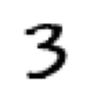

In [13]:
show_image(three_tensors[1]);

对于每个像素位置，我们想要计算该像素强度的所有图像的平均值。为此，我们首先将此列表中的所有图像组合成一个三维张量。描述此类张量的最常见方式是将其称为 rank-3 张量。

可以将二维张量相信成一张纸，所谓合成三维张量就像把多张形状相同的纸（二维张量）一层一层地堆叠起来形成一个长方体。

PyTorch 中的某些作（例如取平均值）需要我们将整数类型转换为浮点类型。由于我们稍后会需要它，因此我们现在还将 stacked tensor 转换为 float。在 PyTorch 中进行强制转换非常简单，只需键入要强制转换的类型的名称，并将其视为一种方法即可。

通常，当图像为浮点数时，像素值预期在 0 和 1 之间，因此我们在这里也要除以 255：

In [14]:
stacked_sevens = torch.stack(seven_tensors).float()/255
stacked_threes = torch.stack(three_tensors).float()/255
stacked_threes.shape

torch.Size([6131, 28, 28])

根据上面执行结果 (6131, 28, 28)

它的形状是 (6131, 28, 28)。这个形状告诉我们：
* 第一个轴（维度）的长度是 6131。这通常表示我们有 6131 个样本，在这个上下文中是 6131 张图像。
* 第二个轴的长度是 28。这通常表示每张图像的高度是 28 像素。
* 第三个轴的长度是 28。这通常表示每张图像的宽度是 28 像素。

对于 PyTorch 来说，一个形状为 (6131, 28, 28) 的张量仅仅是在内存中存储的一串数字，按照这个特定的多维结构排列。**张量的形状只是数据的组织结构，而每个维度代表什么含义，是由我们根据实际应用场景来解释的**


张量形状的长度

In [15]:
len(stacked_threes.shape)

3

张量的**秩就是张量的维度数量，也就是 `shape` 元组的长度。**

* 对于一个标量（例如 `5`），其 `shape` 是 `()`（空元组），因此秩是 0。
* 对于一个向量（例如 `[1, 2, 3]`），其 `shape` 是 `(3,)`，因此秩是 1。
* 对于一个矩阵（例如 `[[1, 2], [3, 4]]`），其 `shape` 是 `(2, 2)`，因此秩是 2。
* 对于我们例子中的图像张量，其 `shape` 是 `(6131, 28, 28)`，因此秩是 3（它是一个 rank-3 张量或三维张量）。

**理解张量的两个基本属性：**
1.  **形状 (shape):** 描述了张量在每个维度上的大小，是理解数据组织方式的关键。
2.  **秩 (rank):** 描述了张量的维度数量。


**rank 是张量中的轴或维度的数量;shape 是张量每个轴的大小**

---

**注意："维度"（dimension）在不同语境下的不同含义**

1. **物理空间中的“维度” vs. 张量的“秩”（rank）**
* 物理空间的三维性：当我们说“三维空间”时，是指描述一个点的位置需要 三个独立参数（例如 x, y, z 坐标）。这里的“维度”指的是 空间方向的数量，每个方向对应一个轴（axis），且每个轴的长度（元素数量）可能不同。

* 张量的秩（rank）：在 PyTorch 中，`v.ndim` 返回张量的 秩（即轴的个数），而非每个轴的长度。例如：

* 一个三维空间位置向量 `v = [1, 2, 3]` 在 PyTorch 中是 一维张量，因为它的 `ndim=1`，仅有一个轴，该轴的长度为 3（`shape=[3]`）。

* 矩阵（二维张量）的 `ndim=2`，因为它有两个轴（行和列）。


> 关键区分：  
> - 物理中的“三维”对应张量的 某个轴的长度（如 `shape=[3]`）；  
> - 张量的“维度”（`ndim`）实际是 秩（轴的个数）。

2. **术语歧义的根源**

* “维度”一词的多义性：

  * 轴的数量（Rank）：在张量中，`ndim` 表示秩（如矩阵是二维张量）。

  * 轴的长度（Size/Shape）：在物理中，“三维”指每个轴的长度（如 `shape=[3]`）。

* 混淆示例：

  * 若有人说“三维张量”，可能指：

    1. 秩为 3 的张量（如 `shape=[2,3,4]`，三个轴）；
    2. 物理空间中某个轴的长度为 3 的张量（如 `shape=[3]`，秩为 1）。

3. **如何避免混淆？**
建议使用无歧义的术语：
* 秩（Rank）：张量的轴数（`ndim`）。

* 轴（Axis）：张量的某个独立方向（如矩阵的行或列）。

* 长度（Shape）：每个轴上的元素数量（如 `shape=[3,4]` 表示第一轴长 3，第二轴长 4）。


举例说明：
* 物理位置向量 `v = [x, y, z]` 在 PyTorch 中：

* 秩为 1（一维张量）；

* 轴长度为 3（`shape=[3]`）；

* 它的“三维性”体现在轴的长度上，而非张量的秩。


4. **总结：理解张量的核心属性**
* `ndim`（秩）：轴的个数（如向量=1，矩阵=2）。

* `shape`（形状）：每个轴的长度（如 `shape=[3,4]` 表示二维张量，第一轴长 3，第二轴长 4）。

* 物理意义的“维度”：通常对应 `shape` 中的某个值，而非 `ndim`。


> 实际应用：在 PyTorch 中，讨论张量时应明确使用 秩、轴、形状，而非物理中的“维度”概念，以避免误解。

也可以使用 ndim 获取张量的秩：

In [16]:
stacked_threes.ndim

3

对于每个像素位置，这将计算该像素在所有图像上的平均值。结果将是每个像素位置一个值，或单个图像

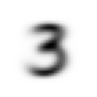

In [17]:
mean3 = stacked_threes.mean(0)
show_image(mean3);

PyTorch张量的 mean 方法表示沿指定维度求均值

* **秩 (Rank)**：指的是张量的**轴的数量**，也就是 `shape` 元组的长度。对于 `stacked_threes`，如果它的形状是 `(num_images, height, width)`，那么它的秩是 **3**。

* **维度 (Dimension) 的索引**：当我们说“维度 0”、“维度 1”、“维度 2” 时，我们是在指张量的**不同轴**。

* **维度的大小 (Length of the axis)**：每个维度都有其大小。在 `stacked_threes` 中：
    * 维度 0 的大小是 `num_images`。
    * 维度 1 的大小是 `height`。
    * 维度 2 的大小是 `width`。

**所以，`stacked_threes` 的秩是 3，表示它有三个轴（维度）。**

你可能会想用“秩”来指代 `num_images`，但更准确的说法是：

* **维度 0 的大小** 表示图像的数量。
* **沿着秩为 0 的轴** 进行 `mean()` 操作，会对所有图像的对应像素取平均。

**为了避免歧义，我们可以这样说：**

在 `stacked_threes` 张量中（假设形状为 `(num_images, height, width)`）：

* **维度 0** 是图像数量的维度，其大小是 `num_images`。
* **维度 1** 是高度的维度，其大小是 `height`。
* **维度 2** 是宽度的维度，其大小是 `width`。

当我们对 `stacked_threes` 使用 `mean(0)` 时，我们是在**沿着图像数量这个维度**进行平均。

**总结：**

* **秩**是轴的数量。
* **维度索引**用于指代特定的轴。
* 每个维度都有其**大小**。

关于mean的参数，对于一个秩为 n 的张量，参数的取值范围是 ​​[-n, n-1]​​，允许正数和负数索引

比如使用 `stacked_threes` 的形状 `(num_images, height, width)` 来解释：

* **正向索引：**
    * 维度 `0` 是第一个维度（图像数量）。
    * 维度 `1` 是第二个维度（高度）。
    * 维度 `2` 是第三个维度（宽度）。

* **负向索引：**
    * 维度 `-1` 是**最后一个**维度（宽度）。
    * 维度 `-2` 是**倒数第二个**维度（高度）。
    * 维度 `-3` 是**倒数第三个**维度（图像数量）。

**所以，负数索引并不是从“不同的方向开始计算”平均值本身，而是提供了一种不同的方式来**指定**你想要进行平均操作的维度。** 计算平均值的过程（对该维度上的所有元素取平均）是相同的，只是你指定维度的**方式**不同。

对 7 做同样的事情

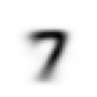

In [18]:
mean7 = stacked_sevens.mean(0)
show_image(mean7);

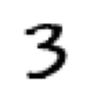

In [19]:
a_3 = stacked_threes[1]
show_image(a_3);


当需要量化图像与理想目标（如数字 "3"）的差异时，直接对像素差异求和会产生误导：正负差异相互抵消（例如某区域过暗补偿另一区域过亮），导致总差异看似为零。为解决此问题，需采用两种数学方法消除符号干扰。

---

**方法一：L1 范数（Mean Absolute Difference）**
1. **计算原理**
* **数学公式**：  

  $ L1 = \frac{1}{n} \sum_{i=1}^{n} |x_i - y_i| $

  其中 \(x_i\) 是实际像素值，\(y_i\) 是理想像素值，\(n\) 是像素总数。

* **关键操作**：  对每个像素的差异取绝对值后求平均，消除正负抵消效应。

2. **技术特性**

* **对异常值的鲁棒性**：  

  L1 对单个大误差的敏感度较低（绝对值线性增长），适用于存在噪声或离群点的场景。例如，若图像局部存在异常光斑，L1 的误差增幅较小。

* **稀疏性优势**：  

  在优化过程中，L1 倾向于产生稀疏解（部分差异归零），有助于识别关键差异区域。

* **计算效率**：  

  无需平方运算，计算速度较快，适用于实时系统。

3. **应用示例**  
假设理想数字 "3" 的某像素值为 200，实际图像中该像素值为 180，另一像素值为 220：  

* **直接差异**：\( (180-200) + (220-200) = -20 + 20 = 0 \)（错误结论）  

* **L1 差异**：\( |180-200| + |220-200| = 20 + 20 = 40 \)（正确反映总差异）


---

**方法二：L2 范数（Root Mean Squared Error, RMSE）**
1. **计算原理**
* **数学公式**：  

  $ L2 = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (x_i - y_i)^2} $
  
  先对差异平方以消除符号，再求均方根。

2. **技术特性**
* **对大差异的敏感性**：  

  平方运算放大较大误差的影响，使模型更关注显著偏离目标的情况。例如，若某像素差异为 50，其对 L2 的贡献为 2500，远高于 L1 的 50。
* **平滑优化特性**：  

  平方函数处处可导，利于梯度下降等优化算法稳定收敛。
* **物理意义**：  

  RMSE 的单位与原始数据一致（因平方根操作），便于直观解释。

3. **应用示例**  
同一场景下：  
* **L2 差异**：

$ \sqrt{(180-200)^2 + (220-200)^2} = \sqrt{400 + 400} ≈ 28.28 $

  相比 L1 的 40，L2 更强调单个像素的偏离程度。

---

**方法对比与选择建议**

| 维度         | L1 范数                          | L2 范数                          |
|-------------------|--------------------------------------|--------------------------------------|
| 误差分布敏感性   | 对异常值不敏感                       | 对大误差敏感                         |
| 优化特性       | 可能收敛至多个局部最优解             | 单一全局最优解                       |
| 计算复杂度     | 低（无需平方运算）                   | 略高（需平方与开方）                 |
| 典型应用场景   | 图像去噪、特征选择               | 高精度配准、质量评估             |


**选择策略**：
* **优先 L1**：若差异分析需排除噪声干扰（如医学图像中的伪影）或强调关键区域。

* **优先 L2**：若需精确量化整体偏离程度（如卫星图像配准）或依赖梯度优化。


---

**扩展：其他相关度量**
1. **Huber Loss**：  
   结合 L1 和 L2 的优点，对小误差使用平方项，对大误差切换为线性项，平衡鲁棒性与敏感性。
2. **结构相似性（SSIM）**：  
   超越像素级差异，从亮度、对比度、结构三方面评估图像相似性，适用于人类视觉感知优化。

---

通过合理选择 L1 或 L2 范数，可有效解决像素差异抵消问题，并为图像质量评估、目标识别等任务提供量化依据。实际应用中常结合交叉验证确定最优方法。

**鲁棒性（Robustness）的定义**

鲁棒性（Robustness）指系统、模型或算法在面对数据扰动、噪声、异常值或分布变化时，仍能保持稳定性和可靠性的能力。在统计学和机器学习中，对异常值的鲁棒性特指模型或方法对数据中极端值（异常值）的敏感度较低，即使存在少量异常值，也能给出准确且一致的结果。

---

**鲁棒性的核心思想**
1. **抗干扰能力**

   鲁棒性强调在数据存在噪声、缺失值或异常值时，模型不会因这些干扰而崩溃或产生严重偏差。例如，使用中位数（而非均值）作为位置估计量时，对极端值的影响更小。  
   * 示例：若数据集包含少数极高薪资（异常值），用均值计算平均薪资会被拉高，而中位数则能更稳健地反映典型薪资水平。


2. **分布适应性**  
   鲁棒方法不依赖严格的数据分布假设（如正态分布），能够适应非对称、偏态或未知分布的数据。  
   * 示例：鲁棒回归模型（如Huber回归）在存在异常值时，仍能拟合出合理的回归线，而普通线性回归可能被异常值严重干扰。


3. **稳定性与泛化性**

   鲁棒模型在训练数据与测试数据分布不同（分布偏移）时，仍能保持较好的性能。例如，在金融欺诈检测中，即使欺诈模式随时间变化，鲁棒模型仍能有效识别新类型的异常交易。

---

**对异常值的鲁棒性具体表现**
1. **异常值敏感性低**  
   * 传统方法问题：如均值和标准差对异常值敏感，一个极端值可能使结果严重偏离真实情况。  

   * 鲁棒替代方法：  

     * 用中位数代替均值，用MAD（Median Absolute Deviation）代替标准差。  

     * 使用L1范数（MAE）而非L2范数（MSE）作为损失函数，减少大误差的权重。


2. **异常值处理机制**  
   * **检测与剔除**：通过统计方法（如箱线图、Z-score）或机器学习方法（如孤立森林、LOF算法）识别异常值，再决定保留、修正或剔除。  

   * **建模兼容性**：鲁棒模型（如随机森林、支持向量机）在训练时自动降低异常值的影响，而非依赖预处理。


3. **结果可靠性**  
   * 即使数据包含一定比例的异常值，鲁棒方法的输出结果仍接近真实值。例如，在图像识别中，鲁棒模型对输入图像的噪声或遮挡具有更强的容忍度。


---

**鲁棒性的应用场景**
1. **数据分析与统计建模**  
   * **金融领域**：处理市场波动中的极端交易数据。  

   * **医疗领域**：识别罕见疾病数据，避免误诊。


2. **机器学习与深度学习**  
   * **异常检测**：如信用卡欺诈检测、工业设备故障预警。  

   * **模型优化**：通过对抗训练、正则化技术（如Dropout、权重约束）提升模型鲁棒性。


3. **工程与控制系统**
   * **自动驾驶**：在传感器噪声或环境干扰下稳定决策。  

   * **制造业**：在设备数据存在测量误差时，仍能准确预测故障。


---

**增强鲁棒性的方法**
1. **数据预处理**  
   * 清洗噪声数据、填充缺失值、标准化/归一化。  

   * 使用重采样技术（如Bootstrap）评估参数稳定性。


2. **算法选择**  
   * 优先选择非参数方法（如K近邻、决策树）或集成学习（如随机森林）。  

   * 采用鲁棒损失函数（如Huber损失、分位数损失）。


3. **模型设计**  
   * 引入正则化（L1/L2正则化）防止过拟合。  

   * 对抗训练：生成对抗样本并加入训练集，提升模型对扰动的抵抗力。


---

**总结**

鲁棒性是现代数据科学和机器学习的核心要求之一，尤其在现实数据普遍存在噪声和异常值的场景下。通过选择鲁棒方法、优化数据流程和模型设计，可显著提升系统在复杂环境中的可靠性。如需进一步了解具体算法（如MAD计算、LOF异常检测）或应用案例，可参考相关文献或技术文档。

In [20]:
# 使用L1范数
dist_3_abs = (a_3 - mean3).abs().mean()
# 使用L2范数
dist_3_sqr = ((a_3 - mean3)**2).mean().sqrt()
dist_3_abs,dist_3_sqr

(tensor(0.1114), tensor(0.2021))

In [21]:
dist_7_abs = (a_3 - mean7).abs().mean()
dist_7_sqr = ((a_3 - mean7)**2).mean().sqrt()
dist_7_abs,dist_7_sqr

(tensor(0.1586), tensor(0.3021))

在这两种情况下，我们的 3 和“理想”3 之间的距离都小于到理想 7 的距离。因此，在这种情况下，我们的简单模型将给出正确的预测。

1.  **PyTorch 提供内置的损失函数：** PyTorch 的 `torch.nn.functional` 模块（通常导入为 `F`）包含了许多常用的神经网络函数，包括我们讨论的平均绝对差（L1 范数）和均方根误差（RMSE 或 L2 范数）。

2.  **推荐的导入方式：** PyTorch 团队建议将 `torch.nn.functional` 模块导入为 `F`。fastai 库也遵循这个惯例，因此在 fastai 环境中，你可以直接使用 `F` 来访问这些函数。

3.  **计算 `a_3` 与 `mean7` 之间的距离：** 代码 `F.l1_loss(a_3.float(), mean7), F.mse_loss(a_3, mean7).sqrt()` 展示了如何使用这两个函数来计算一个数字 3 的图像张量 `a_3` 与“理想”数字 7 的图像张量 `mean7` 之间的距离。


In [22]:
# mse_loss 代表均方误差 ，l1_loss 指的是平均绝对值的标准数学术语（在数学中称为 L1 范数 ）
# L1 范数和均方误差 （MSE） 之间的区别在于，后者会比前者更严厉地惩罚较大的错误（并且对小错误更宽容）
F.l1_loss(a_3.float(),mean7), F.mse_loss(a_3,mean7).sqrt()

(tensor(0.1586), tensor(0.3021))

## 激活函数和损失函数

**损失函数（Loss Function）**

**定义与作用**

损失函数是机器学习与深度学习中用于量化模型预测值与真实值之间差异的数学工具。它通过计算模型输出的误差，为参数优化提供方向，是模型训练的核心指标。

* **核心功能**：

  * **评估性能**：衡量模型预测的准确性，损失值越小表示模型越接近真实结果。

  * **指导优化**：作为优化算法（如梯度下降）的目标函数，通过最小化损失调整模型参数。

  * **正则化**：某些损失函数（如L1/L2）可加入正则项，防止过拟合。


**常见类型**

1. **回归任务**：
   * **L1损失（MAE）**：计算绝对误差，对异常值鲁棒，适用于数据噪声较大的场景。

   * **L2损失（MSE）**：计算平方误差，对离群点敏感，常用于精确回归。

   * **Huber损失**：结合L1和L2特性，对小误差平滑处理，对大误差线性处理，平衡鲁棒性与敏感性。


2. **分类任务**：
   * 交叉熵损失：衡量概率分布差异，多用于分类模型（如逻辑回归、神经网络）。

   * Hinge损失：支持向量机（SVM）的核心，通过最大化分类边界提升稀疏性。

   * 指数损失：AdaBoost算法的关键，对错误分类样本施加指数级惩罚，加速模型迭代。


**应用场景**
* **工业优化**：例如工厂通过损失函数计算最佳通风条件，以最小化额外成本。

* **模型训练**：如PyTorch中的`F.l1_loss`和`F.mse_loss`直接用于参数调优。


---

**激活函数（Activation Function）**

**定义与作用**

激活函数是神经网络中引入非线性的核心组件，决定神经元是否被激活及输出强度，使模型能够拟合复杂数据模式。

* **核心功能**：

  * **引入非线性**：打破线性限制，使网络能够学习复杂函数（如图像识别中的边缘检测）。

  * **梯度控制**：防止梯度消失或爆炸，例如ReLU在正区间保持梯度稳定。

  * **输出规范化**：将输出限制到特定范围（如Sigmoid映射到0-1，适合概率输出）。


**常见类型**
1. **Sigmoid**：输出0-1区间，适用于二分类的概率输出，但易导致梯度消失。
2. **Tanh**：输出-1到1区间，零中心化特性有利于优化过程，但仍存在梯度问题。
3. **ReLU**：正区间梯度为1，计算高效，广泛用于隐藏层，但可能导致“死亡神经元”。
4. **LeakyReLU/ELU**：改进ReLU的负区间处理，缓解神经元死亡问题。
5. **Softmax**：多分类任务中归一化输出为概率分布。

**应用场景**
* **隐藏层**：通常选择ReLU或其变体以提升训练效率。

* **输出层**：根据任务选择激活函数（如二分类用Sigmoid，多分类用Softmax）。


---

**区别与联系**

| 维度       | 损失函数                     | 激活函数                     |
|----------------|----------------------------------|----------------------------------|
| 功能定位   | 全局模型性能评估与优化目标       | 局部神经元非线性转换              |
| 数学作用   | 计算预测值与真实值的误差         | 决定神经元输出值                  |
| 典型示例   | 交叉熵、MSE                     | ReLU、Sigmoid                   |
| 优化关联   | 直接指导参数更新方向             | 影响反向传播梯度计算              |
| 任务适配性 | 需匹配任务类型（分类/回归）      | 需匹配网络层需求（隐藏层/输出层） |

**协同作用**

* 在神经网络中，激活函数处理单层非线性，而损失函数综合各层误差指导整体优化。例如，交叉熵损失需搭配Softmax激活函数实现多分类概率输出。


---

**总结**

损失函数和激活函数是深度学习的核心组件。前者作为“导航仪”评估和优化模型，后者作为“引擎”赋予网络非线性能力。合理选择两者（如回归任务用MSE+ReLU，分类任务用交叉熵+Softmax）可显著提升模型性能。更多细节可参考[PyTorch文档](https://pytorch.org/docs/stable/nn.html#loss-functions)或相关论文。

### NumPy 数组 和 PyTorch 张量


**1. NumPy 与 PyTorch 的共性**

两者均提供多维数组操作的 API，支持高效的数学运算（如矩阵乘法、广播机制等）。例如，以下代码在两种库中行为相似：
```python
# NumPy
import numpy as np
arr = np.array([[1, 2], [3, 4]])
result = arr * 2  # 输出 [[2,4], [6,8]]

# PyTorch
import torch
tensor = torch.tensor([[1, 2], [3, 4]])
result = tensor * 2  # 输出 tensor([[2,4], [6,8]])
```

---

**2. 为何深度学习选择 PyTorch 张量？**

尽管 API 相似，PyTorch 张量在以下关键特性上超越 NumPy 数组：

**（1）GPU 加速支持**

* **PyTorch张量**可通过 `.to("cuda")` 移动到 GPU 上计算，利用 CUDA 并行架构加速大规模矩阵运算。例如：

  ```python
  if torch.cuda.is_available():
      tensor_gpu = tensor.cuda()  # 将张量移至 GPU
  ```
* NumPy：仅支持 CPU 计算，无法直接利用 GPU 的并行能力。


**（2）自动微分（Autograd）**

* **PyTorch**：通过 `requires_grad=True` 跟踪张量操作，使用 `.backward()` 自动计算梯度。例如：

  ```python
  x = torch.tensor(3.0, requires_grad=True)
  y = x**2 + 2*x
  y.backward()  # 自动计算 dy/dx = 8.0
  ```
* **NumPy**：无内置梯度计算功能，需手动实现反向传播。


**（3）动态计算图**

* **PyTorch**：支持动态图机制，允许在运行时根据条件分支或循环修改计算流程。例如：

  ```python
  def dynamic_model(x):
      if x.sum() > 0:
          return x * 2
      else:
          return x - 1
  ```
* **NumPy**：仅提供静态数组操作，无法构建动态计算图。


---

**3. 为何 NumPy 仍不可替代？**

**（1）通用科学计算**

NumPy 是 Python 科学计算生态的基石，与 Pandas、Matplotlib 等库深度集成，适合数据分析、信号处理等非深度学习场景。

**（2）轻量级与稳定性**

对于小规模数据或无需 GPU/梯度计算的场景，NumPy 的 CPU 实现更轻量且稳定。

**（3）协同工作**

两者可通过零拷贝转换无缝协作：
```python
# NumPy 转 Tensor（共享内存）
np_array = np.ones(5)
torch_tensor = torch.from_numpy(np_array)

# Tensor 转 NumPy（共享内存）
torch_tensor = torch.ones(5)
np_array = torch_tensor.numpy()
```

---

**4. 总结与选择建议**

| 维度       | NumPy 数组                  | PyTorch 张量                  |
|----------------|--------------------------------|-----------------------------------|
| 核心用途   | 通用科学计算、数据分析         | 深度学习模型开发与训练            |
| 硬件加速   | 仅 CPU                         | 支持 GPU/CUDA 加速               |
| 自动求导   | 不支持                         | 通过 `autograd` 支持              |
| 动态图     | 不支持                         | 支持运行时动态修改计算流程        |
| 内存管理   | 不可变数组，可能产生内存拷贝   | 视图机制优化内存共享              |

选择策略：
* **深度学习任务**：优先使用 PyTorch 张量，利用其 GPU 加速、自动微分和动态图特性。

* **传统科学计算**：使用 NumPy 数组，结合 Pandas、SciPy 等库完成数据处理。


---

**5. 扩展说明**

• **Fastai 的增强功能**：Fastai 库对 NumPy 和 PyTorch 进行了扩展，使两者的 API 更加接近。例如，用户可通过 `from fastai.vision.all import *` 引入兼容性支持。

• **性能优化**：PyTorch 张量在底层融合操作（如矩阵乘法 + ReLU 激活）以减少 GPU 内核调用次数，而 NumPy 无此类优化。

In [23]:
data = [[1,2,3],[4,5,6]]
# numpy 创建数组
arr = array (data)
# pytorch 创建张量
tns = tensor(data)

In [24]:
arr

array([[1, 2, 3],
       [4, 5, 6]])

In [25]:
tns

tensor([[1, 2, 3],
        [4, 5, 6]])

In [27]:
# 访问 tns 张量的第二个行（索引从 0 开始）。
# tns 是一个 2x3 的张量：
tns[1]



tensor([4, 5, 6])

In [28]:
# 对比NumPy 数组的语法和结果
arr[1]

array([4, 5, 6])

In [29]:
# 这里的 : 表示选择所有行, 后面跟着 1 表示选择索引为 1 的列（即每行的第二个元素）。
tns[:,1]

tensor([2, 5])

In [30]:
# 对比NumPy 数组的语法和结果
arr[:,1]

array([2, 5])

In [31]:
# 1 表示选择索引为 1 的行，即 [4, 5, 6], 后面跟着 1:3 表示在该行中选择从索引 1 开始到索引 3 之前的元素（切片操作）。
tns[1,1:3]

tensor([5, 6])

In [32]:
# 对比NumPy 数组的语法和结果
arr[1,1:3]

array([5, 6])

In [33]:
# 这是一个**广播（broadcasting）**操作。标量 1 会被广播到 tns 张量的每一个元素上，然后进行加法运算。
# tns 的每个元素都会加 1。
tns+1

tensor([[2, 3, 4],
        [5, 6, 7]])

In [34]:
# 对比NumPy 数组的语法和结果
arr+1

array([[2, 3, 4],
       [5, 6, 7]])

In [35]:
# 查看张量类型
tns.type()

'torch.LongTensor'

In [38]:
# NumPy 数组通过python的type返回 arr 对象本身的 Python 类型
type(arr)

numpy.ndarray

In [37]:
# NumPy 数组 通过访问数组属性dtype获取它的数据类型
arr.dtype

dtype('int64')

In [40]:
type(tns)

torch.Tensor

In [41]:
tns.dtype

torch.int64

详细解释一下 `tns.type()`, `tns.dtype`, `type(tns)`, `arr.dtype`, 和 `type(arr)` 之间的区别以及它们的使用场景。

**假设我们有以下 PyTorch 张量 `tns` 和 NumPy 数组 `arr`:**

```python
import torch
import numpy as np

tns = torch.tensor([[1, 2, 3], [4, 5, 6]])
arr = np.array([[1, 2, 3], [4, 5, 6]])
```

**1. `tns.type()` (PyTorch 张量)**

  * **返回值:** 返回一个字符串，表示张量的具体类型，包括其数据类型和所在的设备（例如 CPU 或 CUDA）。
  * **示例:** 对于上面的 `tns`，`tns.type()` 通常会返回 `'torch.LongTensor'`。如果 `tns` 是浮点数张量在 CUDA 上，可能会返回 `'torch.cuda.FloatTensor'`。
  * **用途:** 主要用于获取张量的完整类型信息，包括数据类型和设备信息。在需要打印或记录张量的完整类型时很有用。

**2. `tns.dtype()` (PyTorch 张量)**

  * **返回值:** 返回一个 `torch.dtype` 对象，表示张量中元素的数据类型。
  * **示例:** 对于上面的 `tns`，`tns.dtype` 会返回 `torch.int64` (因为默认情况下整数张量是 64 位整数)。如果创建时指定了 `dtype=torch.int32`，则会返回 `torch.int32`。
  * **用途:** 主要用于获取和设置张量中元素的数据类型。在需要进行类型转换或检查张量的数据类型时非常有用。

**为什么 `tns.type()` 返回 `torch.LongTensor` 而 `tns.dtype()` 返回 `torch.int64`？**

  * `torch.LongTensor` 是 PyTorch 中表示 64 位整数张量的**具体类型名称**。它包含了数据类型 (`torch.int64`) 和张量在 CPU 上的存储方式。
  * `torch.int64` 则是张量中**每个元素的数据类型**，即 64 位整数。

你可以把 `tns.type()` 看作是对 `tns` 更完整的描述，而 `tns.dtype()` 更专注于元素级别的数据类型。

**3. `type(tns)` (PyTorch 张量)**

  * **返回值:** 返回 `tns` 对象本身的 Python 类型。
  * **示例:** 对于任何 PyTorch 张量 `tns`，`type(tns)` 将始终返回 `<class 'torch.Tensor'>`。
  * **用途:** 用于判断 `tns` 是否是一个 PyTorch 张量对象。

**4. `arr.dtype` (NumPy 数组)**

  * **返回值:** 返回一个 `numpy.dtype` 对象，表示数组中元素的数据类型。
  * **示例:** 对于上面的 `arr`，`arr.dtype` 会返回 `int64` (在某些系统上可能是 `int32`)。如果创建时指定了 `dtype=np.float32`，则会返回 `float32`。
  * **用途:** 与 PyTorch 的 `tns.dtype()` 类似，用于获取和设置 NumPy 数组中元素的数据类型。

**5. `type(arr)` (NumPy 数组)**

  * **返回值:** 返回 `arr` 对象本身的 Python 类型。
  * **示例:** 对于任何 NumPy 数组 `arr`，`type(arr)` 将始终返回 `<class 'numpy.ndarray'>`。
  * **用途:** 用于判断 `arr` 是否是一个 NumPy 数组对象。

**总结和使用场景:**

| 操作         | 适用对象      | 返回值类型         | 示例返回值              | 主要用途                                                                 |
|--------------|---------------|------------------|-----------------------|------------------------------------------------------------------------|
| `tns.type()`   | PyTorch 张量  | 字符串            | `'torch.LongTensor'`  | 获取张量的完整类型信息 (数据类型 + 设备)                               |
| `tns.dtype`  | PyTorch 张量  | `torch.dtype` 对象 | `torch.int64`         | 获取/设置张量元素的数据类型，进行类型转换或检查                             |
| `type(tns)`  | PyTorch 张量  | `<class 'torch.Tensor'>` | `<class 'torch.Tensor'>` | 判断对象是否是 PyTorch 张量                                              |
| `arr.dtype`   | NumPy 数组    | `numpy.dtype` 对象 | `int64`               | 获取/设置数组元素的数据类型，进行类型转换或检查                             |
| `type(arr)`   | NumPy 数组    | `<class 'numpy.ndarray'>` | `<class 'numpy.ndarray'>` | 判断对象是否是 NumPy 数组                                                |

**具体使用时机:**

  * 当你需要知道张量是在 CPU 还是 GPU 上，以及它的基本数据类型名称时，使用 `tns.type()`.
  * 当你需要确保张量具有特定的数值数据类型（例如进行浮点运算时需要 `torch.float32`），或者需要将张量转换为不同的数据类型时，使用 `tns.dtype` 或 `arr.dtype`。
  * 当你需要判断一个变量是否是 PyTorch 张量或 NumPy 数组时，使用 `type(tns)` 或 `type(arr)`.

记住，PyTorch 和 NumPy 是独立的库，它们在表示和处理多维数组（张量）时有一些相似的概念，但具体的 API 和类型系统有所不同。理解这些差异对于在深度学习和数值计算中正确地使用这两个库至关重要。

In [42]:
# 如果原始张量 tns 的数据类型是整数类型（例如 torch.int64, torch.int32），
# 那么结果张量的数据类型通常会自动转换为浮点数类型
#（通常是 torch.float32，但也可能是 torch.float64，取决于 PyTorch 的默认设置或张量的初始类型），以保留乘法结果的小数部分。
tns*1.5

tensor([[1.5000, 3.0000, 4.5000],
        [6.0000, 7.5000, 9.0000]])

In [47]:
# NumPy数组的也会根据需要自动转换类型
# 但是NumPy 在打印数组时默认会根据数组的数据类型和数值进行格式化，并且可能会省略小数点后的零
arr*1.5

array([[1.5, 3. , 4.5],
       [6. , 7.5, 9. ]])

接下来需要定义一个指标来判断之前的基准模型是否好用

原文关于指标这段内容核心在于解释**模型评估指标**的重要性，特别是**准确率**在分类任务中的地位，以及使用**验证集**来避免**过拟合**的必要性。

* **模型评估指标的核心概念：** 原文首先指出**指标（metric）**是一个基于模型预测和真实标签计算出来的数值，用于衡量模型的好坏。它提到了回归任务中常用的 **均方误差（MSE）**和 **平均绝对误差（MAE）** 作为例子，但强调这些指标对于大多数人来说不够直观。因此，对于**分类模型**，通常使用 **准确率（Accuracy）**。正如你所解释的，准确率是模型预测正确的样本比例，更易于理解，尤其是在类别分布相对均衡的情况下。

* **验证集的作用与必要性：** 原文接着强调了在 **验证集（validation set）** 上计算评估指标的重要性。这是为了防止模型**过拟合**，即模型只在训练数据上表现良好，而在新数据上表现不佳。验证集作为一个独立的评估数据，可以帮助我们了解模型的泛化能力。你详细阐述了验证集的核心功能（防止过拟合、模型调优与选择）以及常见的使用实践（数据划分方法、交叉验证），这些都进一步强调了验证集在模型开发流程中的关键作用。


* **为何选择准确率**
  * ​直观性​​：准确率易于理解，适合向非技术背景的受众解释模型效果。
  * 低计算成本​​：对于简单模型（如像素相似性模型），准确率计算高效且无需复杂调参

* **为何即使模型简单仍需验证集**
  * 遵循标准流程​​：为后续复杂模型（如神经网络）建立评估规范，确保实践一致性
  * ​早期问题检测​​：验证集可提前暴露数据划分或预处理中的潜在问题（如数据泄露）。

**总结与扩展：**

虽然原文侧重于准确率和验证集，但是在实际应用中，选择合适的评估指标需要考虑数据的**类别平衡情况**和具体的**业务需求**。例如，在类别不平衡时，**F1 分数、精确率、召回率、ROC 曲线和 AUC 值** 等指标能提供更全面的评估。同样，验证集的划分方式也需要根据数据的特性（如时间序列数据）进行调整。

模型评估需要选择合适的指标来衡量性能，而准确率因其直观性常用于分类任务。为了确保模型能够泛化到新数据，避免过拟合，评估过程必须在独立的验证集上进行。即使对于简单的模型，遵循这样的评估流程也是最佳实践，为后续更复杂的模型开发奠定基础，并有助于及早发现潜在问题。

首先从valid目录为 3 和 7 创建张量。这些是我们将用于计算衡量首次尝试模型质量的指标的张量，该指标测量与理想图像的距离：

In [ ]:
# 创建验证集目录下数字3的rank-3 张量
valid_3_tens = torch.stack([tensor(Image.open(o))
                            for o in (path/'valid'/'3').ls()])
# 将张量的数据类型转换为浮点数，并做归一化操作，将像素值从 0-255 的范围缩放到 0-1 的范围。归一化有助于模型的训练过程更加稳定和快速
valid_3_tens = valid_3_tens.float()/255
# 创建验证集目录下数字7的rank-3 张量
valid_7_tens = torch.stack([tensor(Image.open(o))
                            for o in (path/'valid'/'7').ls()])
valid_7_tens = valid_7_tens.float()/255
# 查看valid_3_tens 和 valid_7_tens 这两个张量的形状
valid_3_tens.shape,valid_7_tens.shape

我们看到结果输出两个张量，一个表示 1010 张大小为 28×28 的图像3的验证集，另一个表示 1028 张大小为 28×28 的图像7的验证集。

定义一个mnist_distance 函数，通过计算两张图像对应像素之间绝对差值的平均值，定义了一个简单的图像距离度量。距离越小，表示两张图像在像素层面上越相似。下一步的目标是使用这个距离函数，将任意手写数字图像与数字 3 的平均图像和数字 7 的平均图像进行比较，并将其归类为距离更近的那个数字

In [ ]:
# 参数a: 待测图像张量（如形状为[batch_size, 28, 28]的MNIST图像）
# 参数b: 理想模板图像张量（如mean3或mean7，形状与a相同）
def mnist_distance(a,b):
  return (a-b).abs().mean((-1,-2))

mnist_distance(a_3, mean3)